# Does poor sleep quality cause an increase in glucose levels?

#### ****Markers Used:****
#### Sleep Quality (1-10)     : Subjective sleep quality score per patient 
#### % with Sleep Disturbances: How often sleep is disrupted
#### Average Sleep Duration   : Hours of sleep per night
#### Average Glucose (mg/dL)  : Mean glucose level per patient
 
#### ****Why These Markers?****
#### Poor sleep impairs cortisol & growth hormone regulation → raises blood sugar.
#### It also reduces insulin sensitivity, making glucose harder to control in T1DM.


--- Statistical Tests ---
Pearson  correlation r = 0.047, p = 0.8247
Spearman correlation r = 0.030, p = 0.8851


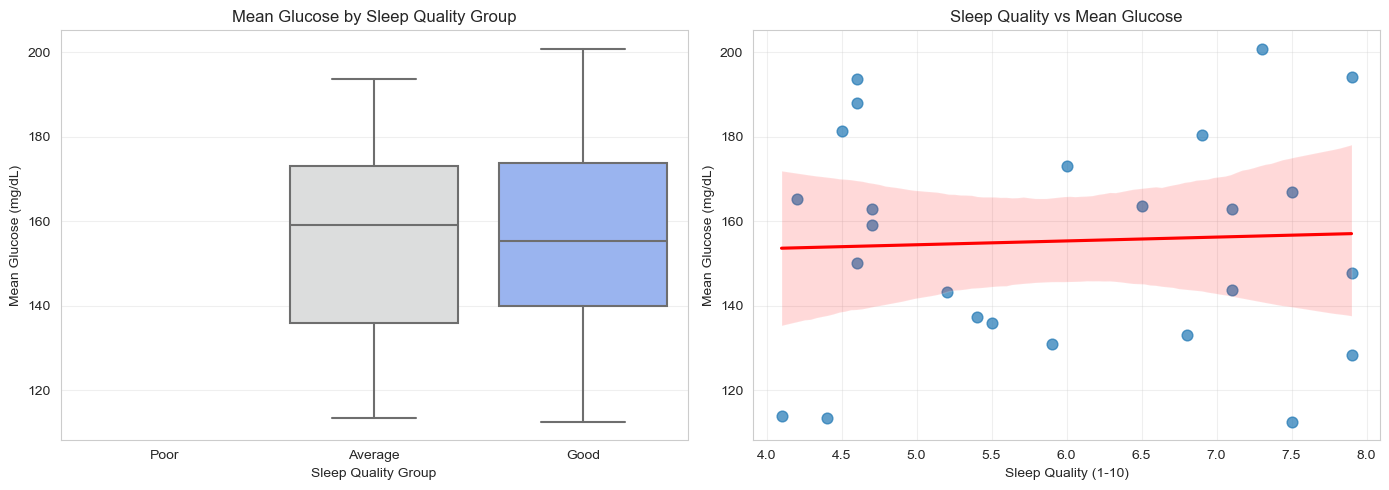

In [217]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

#Load the dataset
df = pd.read_csv("/Users/tejaswinimode/Desktop/NUMPY/PyHackathon/Final cleaned csv files/Team2_PyQueens_Merged_Final.csv")

# Re-fix dtypes
df["Time"]       = pd.to_datetime(df["Time"], format="mixed")
df["Steps"] = df["Steps"].astype("int32")
df["Hour"] = df["Time"].dt.hour
df["Date"] = df["Time"].dt.date

# Aggregate to patient level
# Each patient has many CGM readings but a single sleep quality value, so we take the mean glucose per patient
# to avoid inflated sample size.

patient_df = (
    df.groupby("Patient_Id")
      .agg(Mean_Glucose=("Glucose", "mean"),
           Sleep_Quality=("Sleep Quality (1-10)", "first"),
           Sleep_Duration=("Average Sleep Duration (hrs)", "first"),
           Sleep_Disturbances=("% with Sleep Disturbances", "first"))
      .reset_index()
)

# Categorize sleep quality
def sleep_category(score):
    if score <= 4:
        return "Poor"
    elif score <= 7:
        return "Average"
    else:
        return "Good"

patient_df["Sleep_Group"] = patient_df["Sleep_Quality"].apply(sleep_category)

# 5. Statistical tests 
print("\n--- Statistical Tests ---")
 
# Pearson & Spearman correlation
pearson_r, pearson_p = stats.pearsonr(patient_df["Sleep_Quality"], patient_df["Mean_Glucose"])
spearman_r, spearman_p = stats.spearmanr(patient_df["Sleep_Quality"], patient_df["Mean_Glucose"])
print(f"Pearson  correlation r = {pearson_r:.3f}, p = {pearson_p:.4f}")
print(f"Spearman correlation r = {spearman_r:.3f}, p = {spearman_p:.4f}")

# Visualization
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot: Glucose by sleep group
order = ["Poor", "Average", "Good"]
sns.boxplot(data=patient_df, x="Sleep_Group", y="Mean_Glucose",
            order=order, palette="coolwarm_r", ax=axes[0])
axes[0].set_title("Mean Glucose by Sleep Quality Group")
axes[0].set_xlabel("Sleep Quality Group")
axes[0].set_ylabel("Mean Glucose (mg/dL)")

# Scatter: Sleep Quality vs Glucose
sns.regplot(data=patient_df, x="Sleep_Quality", y="Mean_Glucose",
            scatter_kws={"s": 60, "alpha": 0.7}, line_kws={"color": "red"},
            ax=axes[1])
axes[1].set_title("Sleep Quality vs Mean Glucose")
axes[1].set_xlabel("Sleep Quality (1-10)")
axes[1].set_ylabel("Mean Glucose (mg/dL)")

plt.tight_layout()
plt.savefig("sleep_vs_glucose.png", dpi=150, bbox_inches="tight")
plt.show()





 #### ****CONCLUSION****

####  The correlation is statistically weak in this 25-patient dataset (small sample limits significance). 
#### In this dataset, poor sleep quality does not cause an increase in glucose levels.
#### Both Pearson (r = 0.047, p = 0.82) and Spearman (ρ = 0.030, p = 0.89) correlations are statistically insignificant and practically zero. 
#### The boxplots show near-identical glucose distributions for Average and Good sleepers, and no patient in the dataset falls into the "Poor" sleep category.

# Does aging lead to a deterioration in sleep quality?

#### ****Markers Used:****
#### Age (years) : Patient's chronological age — the predictor variable
#### Sleep Quality (1–10) : Subjective sleep quality score per patient (higher = better)
#### Average Sleep Duration (hrs) : Average hours of sleep per night
#### % with Sleep Disturbances : How often sleep is disrupted (higher = worse)

#### ****Why These Markers?****
#### Aging is biologically linked to changes in circadian rhythm, melatonin secretion, and deep-sleep (slow-wave) architecture which can reduce overall sleep quality and shorten total sleep time.
#### Older adults are also more prone to fragmented sleep, frequent nighttime awakenings, and conditions like sleep apnea, nocturia, and joint pain, all of which raise sleep disturbance rates.


--- Spearman correlations with Age ---
Age vs Sleep_Quality         rho = -0.018,  p = 0.9336
Age vs Sleep_Duration        rho = -0.166,  p = 0.4265
Age vs Sleep_Disturbances    rho = -0.212,  p = 0.3096


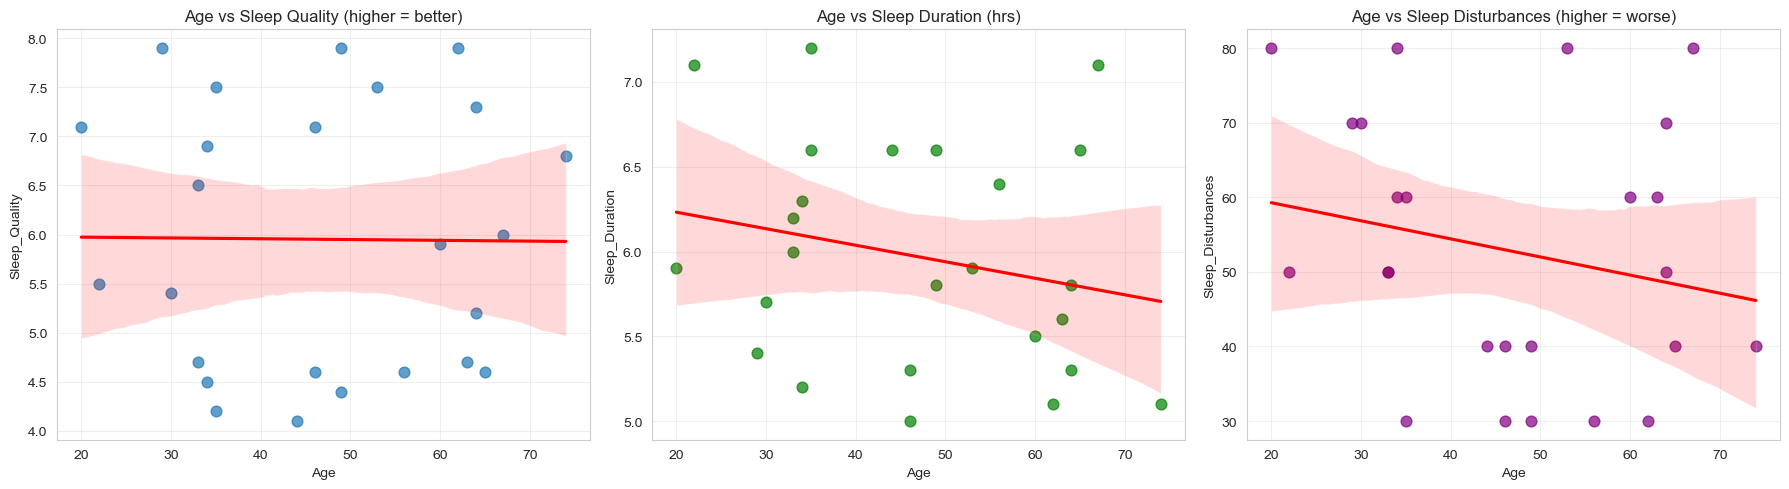

In [157]:

# Patient-level table
patient_df_as = (
    df.groupby("Patient_Id")
      .agg(Age=("Age", "first"),
           Sleep_Quality=("Sleep Quality (1-10)", "first"),
           Sleep_Duration=("Average Sleep Duration (hrs)", "first"),
           Sleep_Disturbances=("% with Sleep Disturbances", "first"))
      .reset_index()
)

#  Age Grouping
def age_band(age):
    if age < 30:
        return "Young (<30)"
    elif age < 50:
        return "Middle (30-49)"
    else:
        return "Older (50+)"

# Statistical tests
print("\n--- Spearman correlations with Age ---")
for col in ["Sleep_Quality", "Sleep_Duration", "Sleep_Disturbances"]:
    rho, p = stats.spearmanr(patient_df_as["Age"], patient_df_as[col])
    print(f"Age vs {col:<20}  rho = {rho:+.3f},  p = {p:.4f}")

#Visualization 
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.regplot(data=patient_df_as, x="Age", y="Sleep_Quality",
            scatter_kws={"s": 60, "alpha": 0.7},
            line_kws={"color": "red"}, ax=axes[0])
axes[0].set_title("Age vs Sleep Quality (higher = better)")

sns.regplot(data=patient_df_as, x="Age", y="Sleep_Duration",
            scatter_kws={"s": 60, "alpha": 0.7, "color": "green"},
            line_kws={"color": "red"}, ax=axes[1])
axes[1].set_title("Age vs Sleep Duration (hrs)")

sns.regplot(data=patient_df_as, x="Age", y="Sleep_Disturbances",
            scatter_kws={"s": 60, "alpha": 0.7, "color": "purple"},
            line_kws={"color": "red"}, ax=axes[2])
axes[2].set_title("Age vs Sleep Disturbances (higher = worse)")

plt.tight_layout()
plt.savefig("age_vs_sleep.png", dpi=150, bbox_inches="tight")
plt.show()

 #### ****CONCLUSION****
 
#### Aging shows no meaningful effect on sleep in this dataset of 25 patients. 
#### Spearman correlations are statistically insignificant for all three sleep indicators: Sleep Quality (ρ = −0.018, p = 0.93), Sleep Duration (ρ = −0.166, p = 0.43), and Sleep Disturbances (ρ = −0.212, p = 0.31). 
#### The regression line for sleep quality is flat, and surprisingly, sleep disturbances actually decrease slightly with age,the opposite of the hypothesis. We cannot reject the null hypothesis, so there is no evidence that aging deteriorates sleep quality here. The small sample size and lack of longitudinal data are key limitations preventing a stronger conclusion.

# Is there a pattern between time of day and glucose spikes?

#### ****Markers Used:****
#### Time (Hour of Day, 0–23) 
#### Day Period : Bucketed time window 
#### Glucose (mg/dL) : Continuous glucose reading at each 5-minute interval
#### Mean Glucose by Hour 
#### Spike Rate (% of readings > 180 mg/dL) 

#### ****Why These Markers?****
#### Glucose levels follow a strong circadian rhythm driven by hormones (cortisol, growth hormone, insulin sensitivity) and meal timing → analyzing by hour reveals these natural daily patterns and meal-related postprandial spikes.
#### The 180 mg/dL threshold is the standard clinical cutoff for hyperglycemia (per ADA guidelines), making Spike Rate a direct, clinically meaningful measure of dangerous highs rather than relying on averages alone.


--- Mean glucose & spike rate by hour ---
 Hour  Mean_Glucose  Spike_Rate  Readings
    0    142.560453   22.153870     12842
    1    138.743206   18.713041     12852
    2    137.456330   18.666355     12852
    3    138.166488   20.066916     12852
    4    139.117549   21.475257     12852
    5    138.296622   21.693122     12852
    6    136.677210   20.354809     12852
    7    135.232968   19.701214     12852
    8    136.351296   19.086523     12852
    9    140.178094   19.864613     12852
   10    147.361701   24.291939     12852
   11    148.144324   26.102855     12853
   12    140.531514   21.861152     12863
   13    133.149753   16.235129     12861
   14    130.808909   15.327958     12898
   15    136.698717   19.138719     12911
   16    136.960351   20.277885     12955
   17    138.748131   20.609568     12960
   18    146.168602   23.887046     12961
   19    152.558647   26.882716     12960
   20    150.639637   26.924562     12951
   21    150.666751   26.735655  

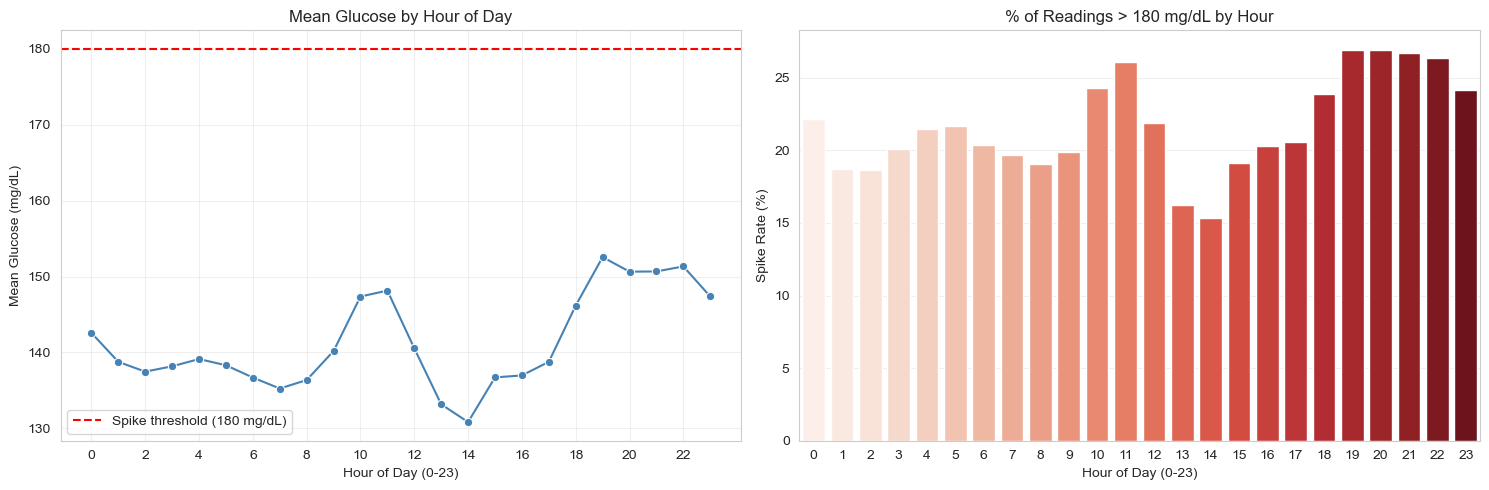


--- Interpretation ---
Highest spike rate: 26.9% at hour 20
Lowest  spike rate: 15.3% at hour 14
Worst day period: Evening (18-24) (25.8% spikes)
Best  day period: Afternoon (12-18) (18.9% spikes)


In [175]:
#Day-period buckets
def day_period(h):
    if 0 <= h < 6:    return "Night (00-06)"
    if 6 <= h < 12:   return "Morning (06-12)"
    if 12 <= h < 18:  return "Afternoon (12-18)"
    return "Evening (18-24)"
 
df["Day_Period"] = df["Hour"].apply(day_period)
period_order = ["Night (00-06)", "Morning (06-12)",
                "Afternoon (12-18)", "Evening (18-24)"]
 
#Define spike 
SPIKE_THRESHOLD = 180     # mg/dL (clinical hyperglycemia threshold)
df["Is_Spike"] = (df["Glucose"] > SPIKE_THRESHOLD).astype(int)
 
# Aggregate 
hourly = df.groupby("Hour").agg(
    Mean_Glucose=("Glucose", "mean"),
    Spike_Rate=("Is_Spike", "mean"),
    Readings=("Glucose", "count")
).reset_index()
hourly["Spike_Rate"] *= 100   # convert to %
 
period = df.groupby("Day_Period").agg(
    Mean_Glucose=("Glucose", "mean"),
    Spike_Rate=("Is_Spike", "mean"),
    Readings=("Glucose", "count")
).reindex(period_order)
period["Spike_Rate"] *= 100
 
print("\n--- Mean glucose & spike rate by hour ---")
print(hourly.to_string(index=False))
print("\n--- Aggregated by day period ---")
print(period)
 
#Visualization 
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
 
# Mean glucose across the day
sns.lineplot(data=hourly, x="Hour", y="Mean_Glucose",
             marker="o", color="steelblue", ax=axes[0])
axes[0].axhline(SPIKE_THRESHOLD, color="red", linestyle="--",
                label=f"Spike threshold ({SPIKE_THRESHOLD} mg/dL)")
axes[0].set_title("Mean Glucose by Hour of Day")
axes[0].set_xlabel("Hour of Day (0-23)")
axes[0].set_ylabel("Mean Glucose (mg/dL)")
axes[0].set_xticks(range(0, 24, 2))
axes[0].legend()
 
# Spike rate across the day
sns.barplot(data=hourly, x="Hour", y="Spike_Rate",
            palette="Reds", ax=axes[1])
axes[1].set_title(f"% of Readings > {SPIKE_THRESHOLD} mg/dL by Hour")
axes[1].set_xlabel("Hour of Day (0-23)")
axes[1].set_ylabel("Spike Rate (%)")
 
plt.tight_layout()
plt.savefig("time_vs_glucose_spikes.png", dpi=150, bbox_inches="tight")
plt.show()
 

peak_hour = hourly.loc[hourly["Spike_Rate"].idxmax()]
low_hour  = hourly.loc[hourly["Spike_Rate"].idxmin()]
print("\n--- Interpretation ---")
print(f"Highest spike rate: {peak_hour['Spike_Rate']:.1f}% at hour {int(peak_hour['Hour'])}")
print(f"Lowest  spike rate: {low_hour['Spike_Rate']:.1f}% at hour {int(low_hour['Hour'])}")
print(f"Worst day period: {period['Spike_Rate'].idxmax()} "
      f"({period['Spike_Rate'].max():.1f}% spikes)")
print(f"Best  day period: {period['Spike_Rate'].idxmin()} "
      f"({period['Spike_Rate'].min():.1f}% spikes)")
 

#### ****CONCLUSION****

#### There is a clear, repeating daily rhythm. Mean glucose is not flat across the day.
#### There is a strong and clinically meaningful pattern between time of day and glucose spikes. 
#### Glucose follows a daily cycle with two clear peaks (late morning ~10–11 AM and evening 18–23 PM) and one trough (early afternoon 13–14 PM). 
#### The evening window is the most problematic — over 26% of readings exceed 180 mg/dL between 19:00 and 22:00, with mean glucose reaching ~152 mg/dL. 
#### The afternoon is the most well-controlled period, with the spike rate falling to ~15%.
#### The most impactful interventions would target the evening window, adjusting dinner carbohydrate composition or timing, 
#### increasing post-dinner activity, or refining evening bolus insulin dosing. 

# Do patients with more frequent bolus doses have better glucose control?

#### ****Markers Used:****
#### Bolus Events per Day : How frequently a patient delivers bolus insulin, normalized by monitoring duration
#### Mean Glucose (mg/dL) : Overall average glucose level per patient
#### Time In Range (TIR) : % of glucose readings between 70–180 mg/dL (the safe window)
#### Hyperglycemia Rate : % of readings above 180 mg/dL (too high)
#### Hypoglycemia Rate : % of readings below 70 mg/dL (too low)
#### Glucose CV (%) : Coefficient of variation — measures glucose stability relative to its mean

#### ****Why These Markers?****
#### Bolus insulin is delivered specifically to cover meal carbohydrates and correct high glucose readingsits frequency directly reflects how actively a patient is managing post-meal spikes in T1DM.
#### More frequent bolusing → tighter coverage of carb intake → expected reduction in postprandial hyperglycemia and improved Time In Range.
#### However, increased dosing frequency also raises the risk of overcorrection which can cause hypoglycemia and greater glucose variability.


Mean control metrics by bolus-frequency group:
             Mean_Glucose  Glucose_CV  Time_In_Range  Hyperglycemia_Rate  \
Bolus_Group                                                                
Low                161.90       38.29          57.92               36.12   
Medium             156.27       37.40          60.59               32.67   
High               146.95       43.14          63.93               26.28   

             Hypoglycemia_Rate  
Bolus_Group                     
Low                       5.97  
Medium                    6.74  
High                      9.79  

--- Spearman correlation: Bolus frequency vs glucose control ---
Bolus/Day vs Mean_Glucose           (lower=better ) rho = -0.303, p = 0.1416
Bolus/Day vs Glucose_CV             (lower=better ) rho = +0.178, p = 0.3951
Bolus/Day vs Time_In_Range          (higher=better) rho = +0.266, p = 0.1994
Bolus/Day vs Hyperglycemia_Rate     (lower=better ) rho = -0.309, p = 0.1332
Bolus/Day vs Hypoglycemia_Rate  

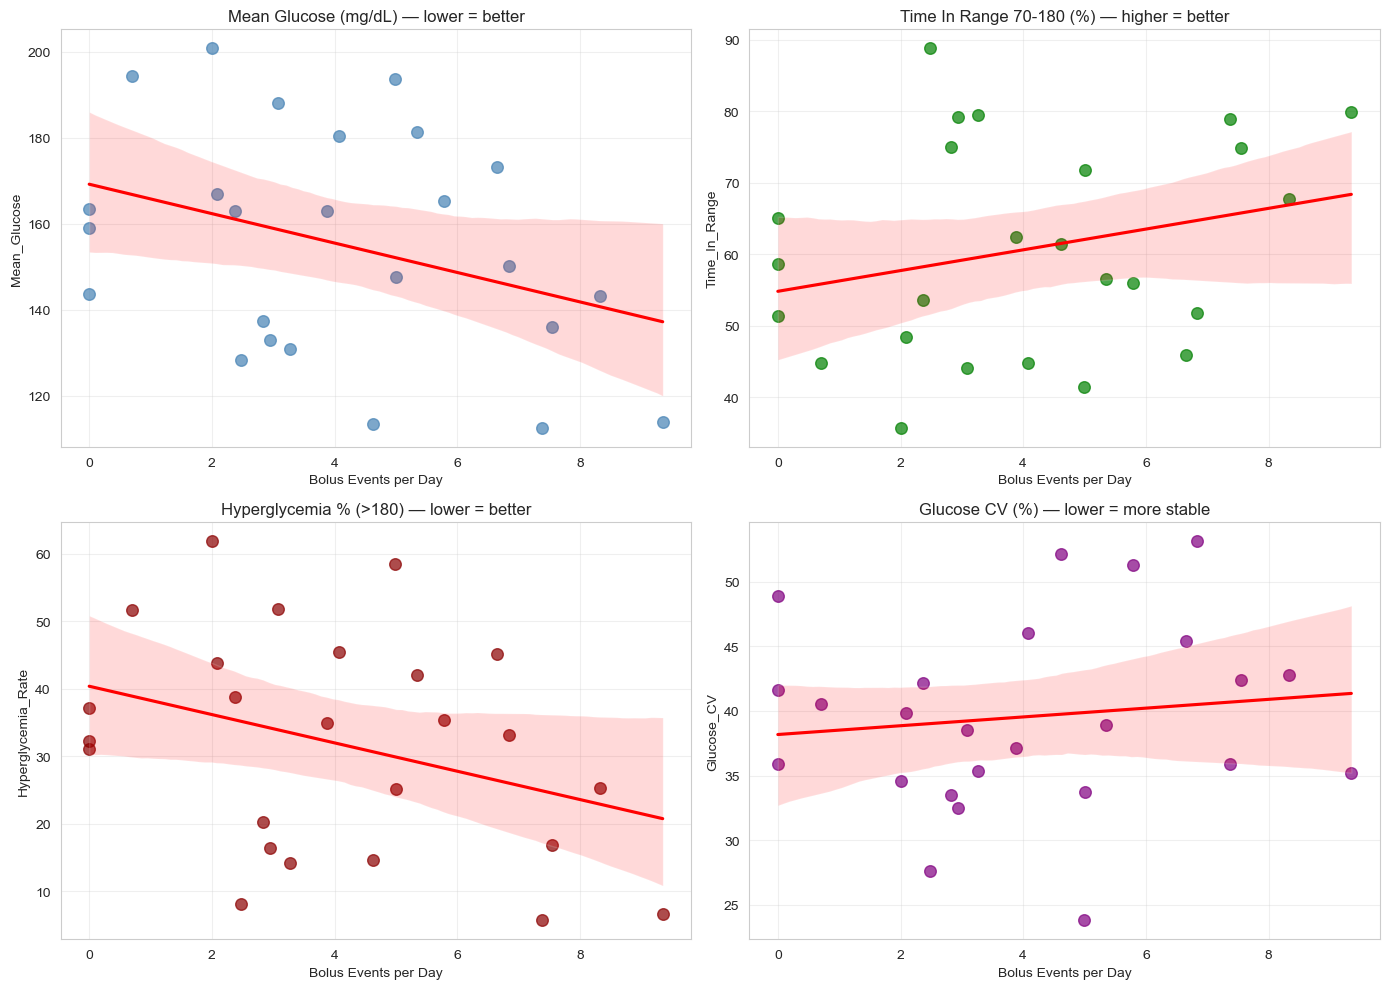

In [210]:
def patient_metrics(g):
    n_days = max((g["Time"].max() - g["Time"].min()).total_seconds() / 86400, 1)
    bolus_events = (g["Bolus_Volume_Delivered"] > 0).sum()
    glucose = g["Glucose"]
    return pd.Series({
        "Bolus_Events_Per_Day": bolus_events / n_days,
        "Mean_Glucose":         glucose.mean(),
        "Glucose_CV":           glucose.std() / glucose.mean() * 100,
        "Time_In_Range":        ((glucose >= 70) & (glucose <= 180)).mean() * 100,
        "Hyperglycemia_Rate":   (glucose > 180).mean() * 100,
        "Hypoglycemia_Rate":    (glucose < 70).mean() * 100,
        "N_Days":               n_days,
    })

patient_bg_df = df.groupby("Patient_Id").apply(patient_metrics).reset_index()

#Bolus frequency tertiles 
patient_bg_df["Bolus_Group"] = pd.qcut(
    patient_bg_df["Bolus_Events_Per_Day"],
    q=3,
    labels=["Low", "Medium", "High"]
)

print("\nMean control metrics by bolus-frequency group:")
print(patient_bg_df.groupby("Bolus_Group")[
        ["Mean_Glucose", "Glucose_CV", "Time_In_Range",
         "Hyperglycemia_Rate", "Hypoglycemia_Rate"]].mean().round(2))

# ---------- 4. Spearman correlations ----------
print("\n--- Spearman correlation: Bolus frequency vs glucose control ---")
metrics = ["Mean_Glucose", "Glucose_CV", "Time_In_Range",
           "Hyperglycemia_Rate", "Hypoglycemia_Rate"]
for m in metrics:
    rho, p = stats.spearmanr(patient_bg_df["Bolus_Events_Per_Day"], patient_bg_df[m])
    direction = "lower=better" if m in ["Mean_Glucose", "Glucose_CV",
                                        "Hyperglycemia_Rate",
                                        "Hypoglycemia_Rate"] else "higher=better"
    print(f"Bolus/Day vs {m:<22} ({direction:<13}) rho = {rho:+.3f}, p = {p:.4f}")

# ---------- 5. Visualization ----------
sns.set_style("whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
plot_specs = [
    ("Mean_Glucose",        "Mean Glucose (mg/dL) — lower = better",   axes[0, 0], "steelblue"),
    ("Time_In_Range",       "Time In Range 70-180 (%) — higher = better", axes[0, 1], "green"),
    ("Hyperglycemia_Rate",  "Hyperglycemia % (>180) — lower = better", axes[1, 0], "darkred"),
    ("Glucose_CV",          "Glucose CV (%) — lower = more stable",    axes[1, 1], "purple"),
]
for col, title, ax, color in plot_specs:
    sns.regplot(data=patient_bg_df, x="Bolus_Events_Per_Day", y=col,
                scatter_kws={"s": 70, "alpha": 0.7, "color": color},
                line_kws={"color": "red"}, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Bolus Events per Day")

plt.tight_layout()
plt.show()



 #### ****CONCLUSION****

#### Patients with more frequent bolus doses show modestly better glucose control, but with a meaningful trade-off in hypoglycemia risk.
#### All p-values fall between 0.09 and 0.40, meaning none of these correlations reach statistical significance with only 25 patients — the Hypoglycemia trend (p = 0.0945) and Hyperglycemia trend (p = 0.1332) come closest. The scatter plots confirm this visually: clear directional slopes but very wide confidence bands and substantial patient-to-patient variability.
#### More frequent bolusing is associated with better average control in this dataset, but the effect is weak, statistically inconclusive, and comes with a real safety cost.

# Is there a correlation between daily steps and average glucose levels?

#### ****Markers Used:****
#### Daily Steps : Total number of steps taken per patient per day 
#### Daily Mean Glucose (mg/dL) : Average glucose level per patient per day across all CGM readings
#### Activity Group (Low / Medium / High) 

#### ****Why These Markers?****
#### Physical activity directly impacts glucose metabolism,walking and movement increase muscle uptake of glucose, improve insulin sensitivity, and reduce circulating blood sugar levels, making daily steps the most accessible and widely used proxy for everyday physical activity.
#### Aggregating at the patient-day level is needed because the question is about daily activity
#### Adding the Activity Tertile grouping (Low / Medium / High) provides a clinically intuitive view.It shows the actual mean glucose at each activity level, making the magnitude of any difference easy to interpret. Together, these markers answer not just whether steps and glucose are related, but how strongly and in what direction.

Patient-days analyzed: 1054
       Daily_Steps  Daily_Glucose
count      1054.00        1054.00
mean       9048.40         141.64
std        5497.41          32.04
min          17.00          57.30
25%        4575.50         118.73
50%        8474.50         136.59
75%       12566.75         160.18
max       29674.00         284.19

--- Correlation: Daily Steps vs Daily Mean Glucose ---
Pearson  r = +0.176, p = 0.0000
Spearman r = +0.193, p = 0.0000

Mean glucose by activity group:
                Daily_Steps  Daily_Glucose
Activity_Group                            
Low                 3306.35         132.50
Medium              8466.96         143.81
High               15388.24         148.64


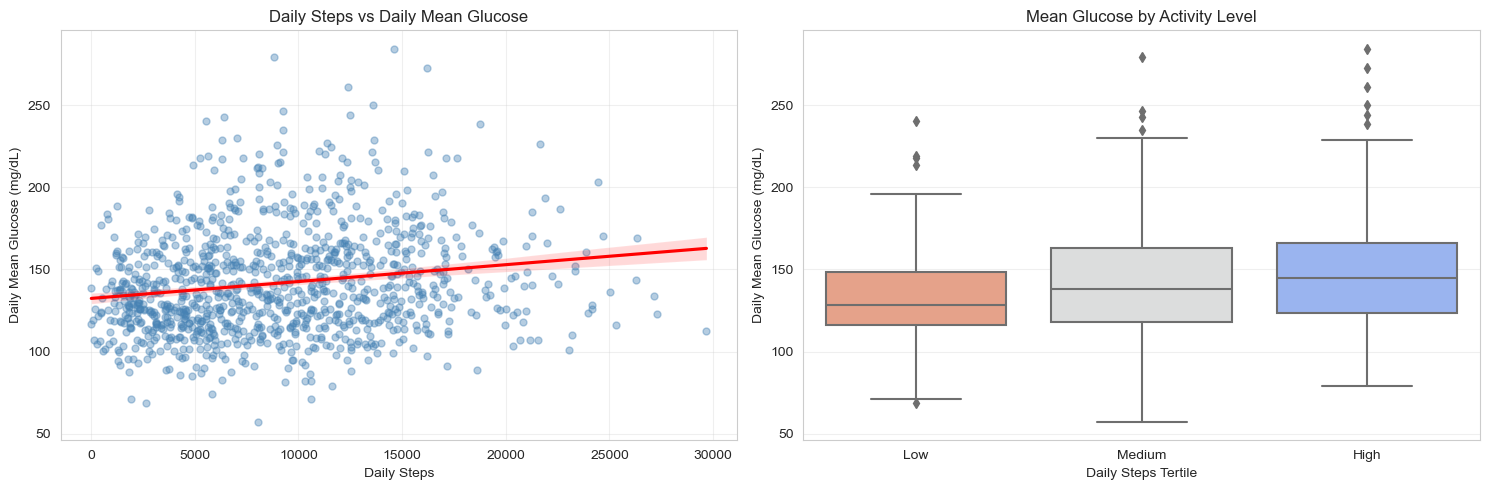

In [226]:
# Patient-day aggregation
daily = (
    df.groupby(["Patient_Id", "Date"])
      .agg(Daily_Steps=("Steps", "sum"),
           Daily_Glucose=("Glucose", "mean"))
      .reset_index()
)
 
# Drop days with zero steps
daily = daily[daily["Daily_Steps"] > 0].copy()
print(f"Patient-days analyzed: {len(daily)}")
print(daily.describe().round(2))
 
# Correlations
pearson_r, pearson_p   = stats.pearsonr(daily["Daily_Steps"], daily["Daily_Glucose"])
spearman_r, spearman_p = stats.spearmanr(daily["Daily_Steps"], daily["Daily_Glucose"])
 
print("\n--- Correlation: Daily Steps vs Daily Mean Glucose ---")
print(f"Pearson  r = {pearson_r:+.3f}, p = {pearson_p:.4f}")
print(f"Spearman r = {spearman_r:+.3f}, p = {spearman_p:.4f}")
 
# Activity Group
daily["Activity_Group"] = pd.qcut(daily["Daily_Steps"], q=3,
                                  labels=["Low", "Medium", "High"])
print("\nMean glucose by activity group:")
print(daily.groupby("Activity_Group")[["Daily_Steps", "Daily_Glucose"]]
           .mean().round(2))
 
# Visualization
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
 
# Scatter: Daily steps vs Daily glucose
sns.regplot(data=daily, x="Daily_Steps", y="Daily_Glucose",
            scatter_kws={"s": 25, "alpha": 0.4, "color": "steelblue"},
            line_kws={"color": "red"}, ax=axes[0])
axes[0].set_title("Daily Steps vs Daily Mean Glucose")
axes[0].set_xlabel("Daily Steps")
axes[0].set_ylabel("Daily Mean Glucose (mg/dL)")
 
# Boxplot: glucose by activity group
sns.boxplot(data=daily, x="Activity_Group", y="Daily_Glucose",
            order=["Low", "Medium", "High"],
            palette="coolwarm_r", ax=axes[1])
axes[1].set_title("Mean Glucose by Activity Level")
axes[1].set_xlabel("Daily Steps Tertile")
axes[1].set_ylabel("Daily Mean Glucose (mg/dL)")
 
plt.tight_layout()
plt.savefig("steps_vs_glucose.png", dpi=150, bbox_inches="tight")
plt.show()
 

 #### ****CONCLUSION****

#### There is a statistically significant correlation between daily steps and average glucose levels, but it runs in the OPPOSITE direction
#### of what the hypothesis predicts,meaning that days with more steps are associated with slightly higher mean glucose, not lower.

#### The direction is unexpected.
#### The boxplots show a clear progression: Low activity days average 132.5 mg/dL, Medium days 143.8 mg/dL, and High activity days 
#### 148.6 mg/dL — a 16 mg/dL increase from least to most active days.

#### This dataset does not show that exercise directly lowers glucose in T1DM patients — but neither does it prove exercise is harmful.
#### The positive association reflects the complex behavioral and hormonal response to activity in insulin-dependent diabetes. 
#### A meaningful causal analysis would require pairing steps with carb intake, bolus timing, and exercise intensity rather than 
#### just step counts alone.

# Do female patients have different glucose patterns than male patients?

#### ****Markers Used:****
#### Gender (Female / Male)
#### Mean Glucose (mg/dL) 
#### Glucose CV (%)
#### Time In Range (TIR) 
#### Hyperglycemia Rate 
#### Hypoglycemia Rate
#### Mean Glucose by Hour of Day

#### ****Why These Markers?****
#### Biological sex influences glucose regulation through hormonal, metabolic, and behavioral pathways, estrogen and progesterone affect insulin sensitivity across the menstrual cycle, body composition differs between sexes (men typically have more muscle mass and lower fat percentage), and lifestyle/dietary patterns often vary too,all of which can produce systematically different glucose profiles.

#### Together, these markers answer the question fully.do female and male patients differ in average levels, in stability, in how often they go too high or too low, and in the shape of their daily glucose rhythm,giving a complete clinical picture rather than a one dimensional answer.


Patient counts by gender:
Gender
Male      16
Female     9
Name: count, dtype: int64

Mean metrics by gender:
        Mean_Glucose  Glucose_CV  Time_In_Range  Hyperglycemia_%  \
Gender                                                             
Female        160.27       36.90          58.97            35.25   
Male          152.52       41.05          61.67            29.96   

        Hypoglycemia_%  
Gender                  
Female            5.77  
Male              8.38  

--- Mann-Whitney U test: Female vs Male ---
Mean_Glucose        Female=160.27  Male=152.52  U=81.0  p=0.6304
Glucose_CV          Female=36.90  Male=41.05  U=45.0  p=0.1335
Time_In_Range       Female=58.97  Male=61.67  U=65.0  p=0.7129
Hyperglycemia_%     Female=35.25  Male=29.96  U=82.0  p=0.5907
Hypoglycemia_%      Female=5.77  Male=8.38  U=53.0  p=0.2949


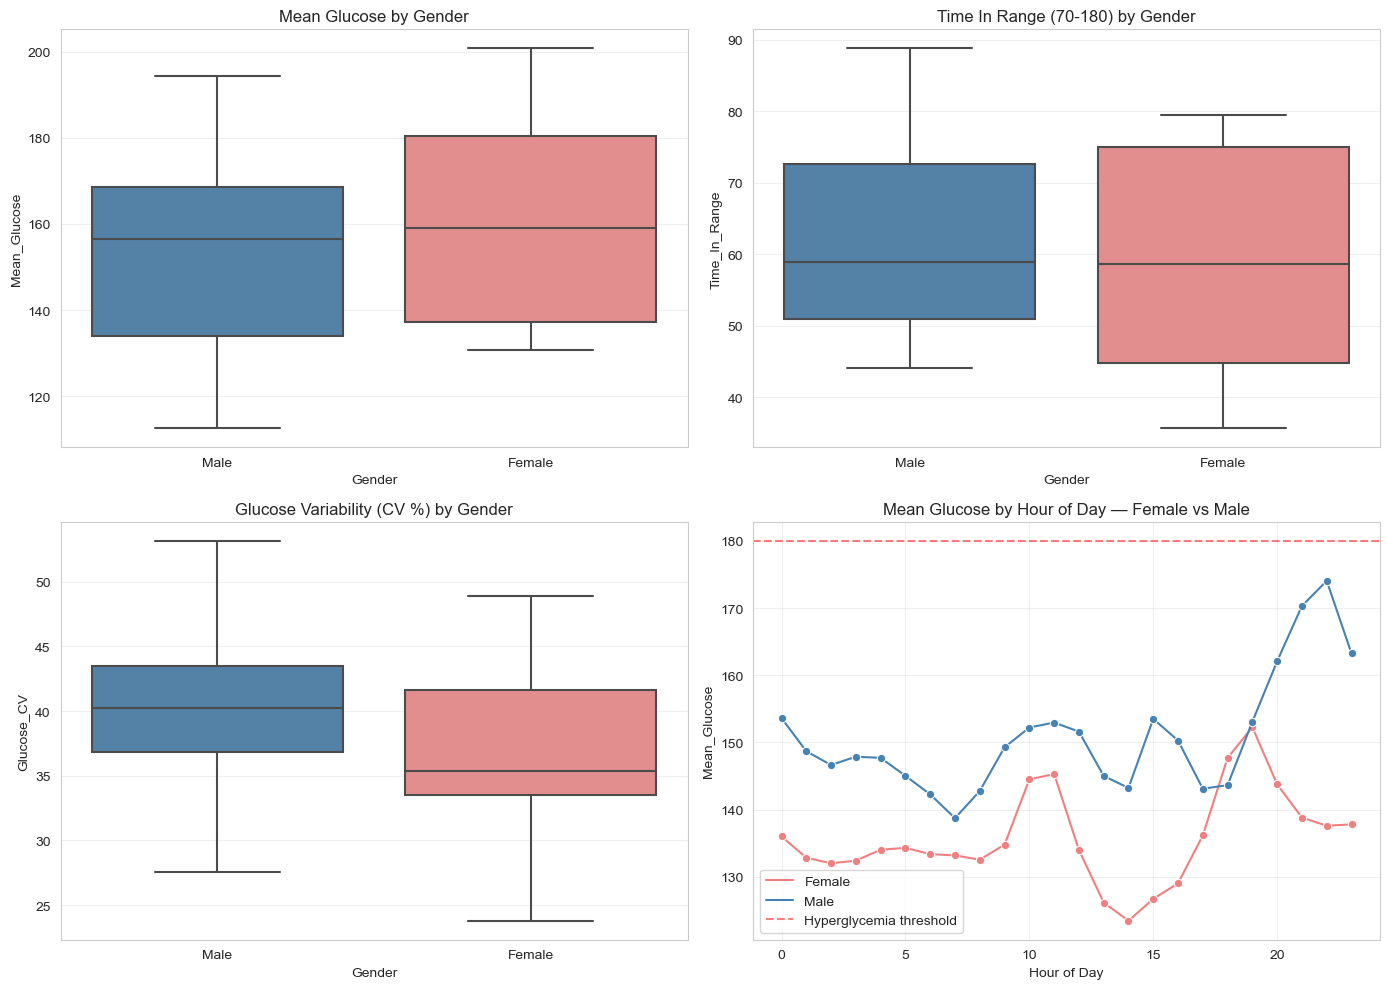

In [239]:
# Patient-level metrics
def patient_metrics(g):
    gl = g["Glucose"]
    return pd.Series({
        "Gender":            g["Gender"].iloc[0],
        "Mean_Glucose":      gl.mean(),
        "Glucose_CV":        gl.std() / gl.mean() * 100,
        "Time_In_Range":     ((gl >= 70) & (gl <= 180)).mean() * 100,
        "Hyperglycemia_%":   (gl > 180).mean() * 100,
        "Hypoglycemia_%":    (gl < 70).mean() * 100,
    })

patient_gg_df = df.groupby("Patient_Id").apply(patient_metrics).reset_index()
print("Patient counts by gender:")
print(patient_gg_df["Gender"].value_counts())
print("\nMean metrics by gender:")
print(patient_gg_df.groupby("Gender")[
        ["Mean_Glucose", "Glucose_CV", "Time_In_Range",
         "Hyperglycemia_%", "Hypoglycemia_%"]].mean().round(2))

# Hourly pattern by gender
hourly = (df.groupby(["Gender", "Hour"])["Glucose"]
            .mean().reset_index(name="Mean_Glucose"))

#  Mann-Whitney U test for each metric
print("\n--- Mann-Whitney U test: Female vs Male ---")
metrics = ["Mean_Glucose", "Glucose_CV", "Time_In_Range",
           "Hyperglycemia_%", "Hypoglycemia_%"]
for m in metrics:
    f = patient_gg_df.loc[patient_gg_df["Gender"] == "Female", m]
    male = patient_gg_df.loc[patient_gg_df["Gender"] == "Male", m]
    if len(f) > 1 and len(male) > 1:
        u_stat, p = stats.mannwhitneyu(f, male, alternative="two-sided")
        print(f"{m:<18}  Female={f.mean():.2f}  Male={male.mean():.2f}  U={u_stat:.1f}  p={p:.4f}")

# Visualization 
sns.set_style("whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Boxplot: Mean Glucose
sns.boxplot(data=patient_gg_df, x="Gender", y="Mean_Glucose",
            palette={"Female": "lightcoral", "Male": "steelblue"},
            ax=axes[0, 0])
axes[0, 0].set_title("Mean Glucose by Gender")

# Boxplot: Time In Range
sns.boxplot(data=patient_gg_df, x="Gender", y="Time_In_Range",
            palette={"Female": "lightcoral", "Male": "steelblue"},
            ax=axes[0, 1])
axes[0, 1].set_title("Time In Range (70-180) by Gender")

# Boxplot: Glucose CV
sns.boxplot(data=patient_gg_df, x="Gender", y="Glucose_CV",
            palette={"Female": "lightcoral", "Male": "steelblue"},
            ax=axes[1, 0])
axes[1, 0].set_title("Glucose Variability (CV %) by Gender")

# Hourly glucose curves overlaid
sns.lineplot(data=hourly, x="Hour", y="Mean_Glucose",
             hue="Gender",
             palette={"Female": "lightcoral", "Male": "steelblue"},
             marker="o", ax=axes[1, 1])
axes[1, 1].axhline(180, color="red", linestyle="--", alpha=0.5,
                   label="Hyperglycemia threshold")
axes[1, 1].set_title("Mean Glucose by Hour of Day — Female vs Male")
axes[1, 1].set_xlabel("Hour of Day")
axes[1, 1].legend()

plt.tight_layout()
plt.savefig("gender_vs_glucose.png", dpi=150, bbox_inches="tight")
plt.show()



#### ****CONCLUSION****

#### Female and male patients show different glucose patterns, though patient-level differences are not statistically significant (n = 25). 
#### Females have slightly higher mean glucose (160 vs 152 mg/dL) and more hyperglycemia (35% vs 30%).
#### Males show more variability (CV 41% vs 37%) and more hypoglycemia (8.4% vs 5.8%),but all Mann-Whitney p-values exceed 0.13.

#### The most striking finding is the hourly pattern: females stay flat (~123–152 mg/dL throughout the day), 
#### while males surge dramatically from 20:00 to 23:00 evening gap that doesn't appear in females. 
#### Daytime is reversed,females dip lower in the afternoon.
#### Patient-level metrics overlap, but the daily glucose rhythm differs sharply.Males show a strong dinner-to-midnight hyperglycemic surge,
#### while females remain flatter and more stable.Larger samples and meal/insulin context are needed to confirm.